__Assignment 3__  
__Name: Bryan Lim Li Cheng__  
__Student ID: 2301214__  

# CSD3185/CSD3186: Assignment 3

## Topics Covered:  
- Data Preprocessing
- K-Means
- Principal Component Analysis (PCA)
- Decision Tree Classifier

## Python and Dependency Versions  
To ensure reproducibility and compatibility, please check that you have the following Python and dependency versions installed:

- Python >= 3.12
- pandas == 2.3.3
- numpy == 2.4.1
- matplotlib == 3.10.8
- scikit-learn == 1.8.0

## Assignment Overview

This assignment is divided into **two parts**, each using a different real-world dataset to practise key machine learning concepts including data preprocessing, unsupervised learning, and supervised learning.



### Part A — Spotify Song Attributes (`Spotify_Song_Attributes.csv`)

In this part, you will work with a dataset containing audio features of Spotify songs. Your tasks will involve:

- **Data Preprocessing** — Loading the dataset, selecting relevant audio features, handling missing values, removing duplicates, and standardizing the data using `StandardScaler`.
- **Principal Component Analysis (PCA)** — Applying PCA to reduce the dimensionality of the data, determining the optimal number of components needed to explain at least 90% of the variance, and visualizing the cumulative explained variance.
- **K-Means Clustering** — Clustering songs based on their audio characteristics using K-Means, determining the optimal number of clusters using the elbow method and silhouette scores, and visualizing the resulting clusters.

---

### Part B — Titanic Survival Prediction (`titanic_train.csv` & `titanic_test.csv`)

In this part, you will work with the classic Titanic dataset, split into separate training and test files. Your tasks will involve:

- **Data Cleaning** - Analyze and determine what to clean in the dataset.
- **Data Preprocessing** - Analyze and determine what to preprocess in the dataset.
- **Classification Modeling** — Training a **Decision Tree Classifier** on the preprocessed training data and evaluating its performance on the test set, with the goal of achieving the highest possible accuracy without overfitting.

---

> 💡 **Tip:** Complete the tasks in order, as some later tasks build upon earlier ones. Make sure to read each task carefully before writing your code.

## Deliverables

Your submission for this assignment should be only __ONE__ file - this particular completed notebook file. 

Also, *RENAME* your file like this: __\<coursecode\>\_<assignment#>\_<your_full_name>.ipynb__  
Eg. CS3185_A3_John_Doe.ipynb  

To complete this assignment, you should follow instructions in below section Tasks.

## IMPORTANT! READ THIS BEFORE STARTING...
- DO NOT delete existing cells, but you can add more cells anywhere in the notebook as necessary.
- DO NOT modify or comment out the content of the existing cells unless otherwise stated (e.g., for code implementation). However, DO NOT change the variable names that are already defined in the existing cells.
- Follow the file naming convention for the notebook file as spelled out above strictly.

Please adhere strictly to the instructions as stated above as failure to do so might result in deduction of marks by the autograder.

Your assignment begins after the line below!! Complete all the tasks as specified.

---

## Part A — Spotify Song Attributes

## 1. Data Loading and Preprocessing

Load some basic libraries upfront. You may add any other libraries you deem necessary below or later on where appropriate.

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

__Task 1.1__

Load the Spotify songs dataset from the provided CSV file into a pandas DataFrame called `data`.

In [23]:
# read the dataset as a pandas DataFrame into `data`
# place dataset in the same folder as this notebook; load it by filename only (no paths).
data = pd.read_csv("Spotify_Song_Attributes.csv")

__Task 1.2__ [optional but recommended]

Perform basic exploration of the dataset to understand more about its structure and content. Feel free to do any kind of exploration in this task.

In [24]:
data_shape = data.shape


In [25]:
data_shape

(10080, 22)

__Task 1.3__

We want to cluster the songs based on certain audio characteristics, hence extract the following subset of audio features only from the dataset:

- danceability
- energy
- key
- loudness
- mode
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo
- time_signature

Store the newly created subset of features in a DataFrame under `data_sub`. For the rest of the assignment, we will only work with this subset of features.

In [26]:
audio_features = [
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'time_signature'
]

data_sub = data[audio_features]

In [27]:
data_sub.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,0.476,0.799,4.0,-4.939,0.0,0.2120,0.0162,0.000000,0.2570,0.577,162.139,4.0
1,0.475,0.130,7.0,-17.719,1.0,0.0510,0.9160,0.956000,0.1010,0.122,112.241,4.0
2,0.691,0.814,1.0,-3.788,0.0,0.1170,0.0164,0.000000,0.3660,0.509,132.012,4.0
3,0.624,0.596,4.0,-9.804,1.0,0.0314,0.4750,0.203000,0.1190,0.896,120.969,4.0
4,0.625,0.726,11.0,-11.402,0.0,0.0444,0.0158,0.000169,0.0625,0.507,124.945,4.0


__Task 1.4__

Use an appropriate pandas method to calculate and display the number of missing values in each column.

In [28]:
missing_values = data_sub.isnull().sum()
missing_values

danceability        550
energy              550
key                 550
loudness            550
mode                550
speechiness         550
acousticness        550
instrumentalness    550
liveness            550
valence             550
tempo               550
time_signature      550
dtype: int64

Display the rows with missing values.

In [29]:
data_sub[data_sub.isnull().any(axis=1)]

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
10063,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10066,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Drop the rows with missing values from `data_sub` and save the result to `data_sub_no_na`.

In [30]:
data_sub_no_na = data_sub.dropna()
data_sub_no_na.shape

(9530, 12)

__Task 1.5__

Check for any duplicate rows in `data_sub_no_na` and remove them if there are any. Save the result to `data_sub_no_dup`.

In [31]:
print(data_sub_no_na.duplicated().sum())  # Shows count of duplicate rows

# Remove duplicates and save to new var
data_sub_no_dup = data_sub_no_na.drop_duplicates()

4797


In [32]:
data_sub_no_dup.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,0.476,0.799,4.0,-4.939,0.0,0.2120,0.0162,0.000000,0.2570,0.577,162.139,4.0
1,0.475,0.130,7.0,-17.719,1.0,0.0510,0.9160,0.956000,0.1010,0.122,112.241,4.0
2,0.691,0.814,1.0,-3.788,0.0,0.1170,0.0164,0.000000,0.3660,0.509,132.012,4.0
3,0.624,0.596,4.0,-9.804,1.0,0.0314,0.4750,0.203000,0.1190,0.896,120.969,4.0
4,0.625,0.726,11.0,-11.402,0.0,0.0444,0.0158,0.000169,0.0625,0.507,124.945,4.0


__Task 1.6__

Create a correlation matrix of the features in `data_sub_no_dup` and plot a heatmap to visualize the correlations. 

Assign the heatmap plotting to the variable `corr_heatmap`.

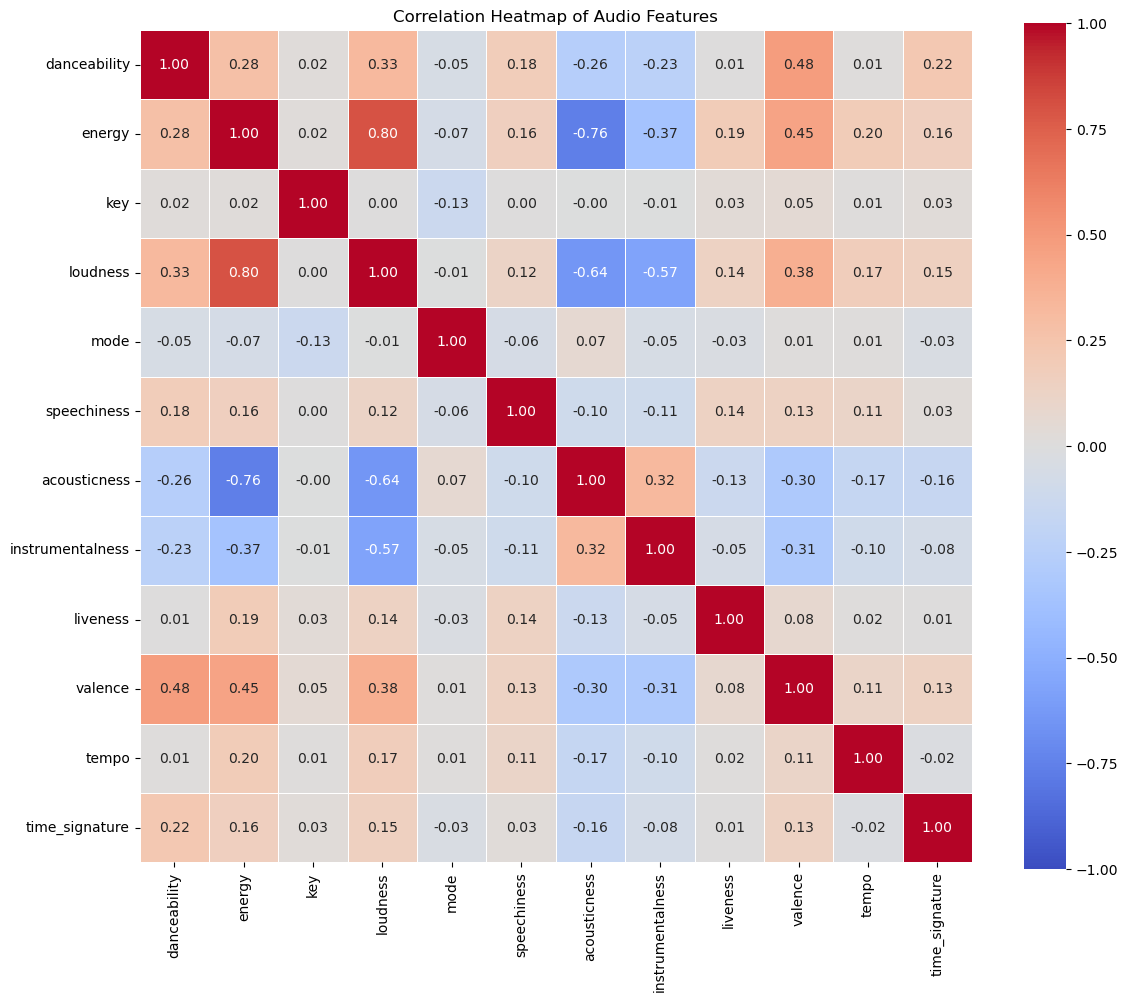

<Axes: title={'center': 'Correlation Heatmap of Audio Features'}>

In [34]:
# Compute pairwise correlation of features using pandas
data_corr = data_sub_no_dup.corr()

# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the heatmap
corr_heatmap = sns.heatmap(
    data_corr,
    annot=True,       # Show correlation values in each cell
    fmt=".2f",        # Format values to 2 decimal places
    cmap="coolwarm",  # Color scheme: blue (negative) to red (positive)
    vmin=-1, vmax=1,  # Fix scale from -1 to 1
    square=True,      # Make cells square-shaped
    linewidths=0.5,   # Add gridlines between cells
    ax=ax
)

plt.title("Correlation Heatmap of Audio Features")
plt.tight_layout()
plt.show()

corr_heatmap

__Task 1.7__

Standardize the features in `data_sub_no_dup` using **`StandardScaler`** from scikit-learn. 

Save the standardized features to a new DataFrame called `data_sub_scaled` along with the original column names.

In [39]:
# Init standard scaler
scaler = StandardScaler()

# Fit and transform data
scaled_data = scaler.fit_transform(data_sub_no_dup)

# Convert back to dataframe with original col names
data_sub_scaled = pd.DataFrame(scaled_data, columns = data_sub_no_dup.columns)

In [40]:
data_sub_scaled.shape

(4733, 12)

__Task 1.8__

Perform Principal Component Analysis (PCA) on the standardized features in `data_sub_scaled` using **`PCA`** from scikit-learn.

Create a PCA object with `random_state=42` and save it in a variable called `pca`.
Then fit it to the standardized data (no transformation needed here).

In [42]:
pca = PCA(random_state = 42)
pca.fit(data_sub_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


__Task 1.9__

Examine the explained variance ratio of the PCA components and determine how many components are needed to explain at least 90% of the variance in the data.

Write a function called `get_n_components` that takes the following parameters:
- `pca` : a fitted PCA object
- `threshold` : a float representing the minimum cumulative explained variance ratio (default value of `0.90`)

The function should return the **minimum number of PCA components** needed to explain at least `threshold` of the variance in the data.

In [43]:
def get_n_components(pca, threshold=0.90):
    """
    Determine the minimum number of PCA components needed to explain
    at least a given threshold of the total variance in the data.

    Parameters
    ----------
    pca : sklearn.decomposition.PCA
        A fitted PCA object containing the explained variance ratios
        of each principal component.
    threshold : float, optional
        The minimum cumulative explained variance ratio to achieve.
        Must be a value between 0 and 1. Default is 0.90.

    Returns
    -------
    int
        The minimum number of principal components needed to explain
        at least `threshold` of the total variance.
    """
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    return int(n_components)



# Call the function, save result in `n_components_90`
n_components_90 = get_n_components(pca)
n_components_90

9

__Task 1.10__  

Create a plot of the cumulative explained variance ratio against the number of PCA components to visualize how the variance is explained as we include more components and also to verify the result from previous task.

Complete the function `plot_cumulative_explained_variance` to create a line plot showcasing the explained variance ratio vs principal components.

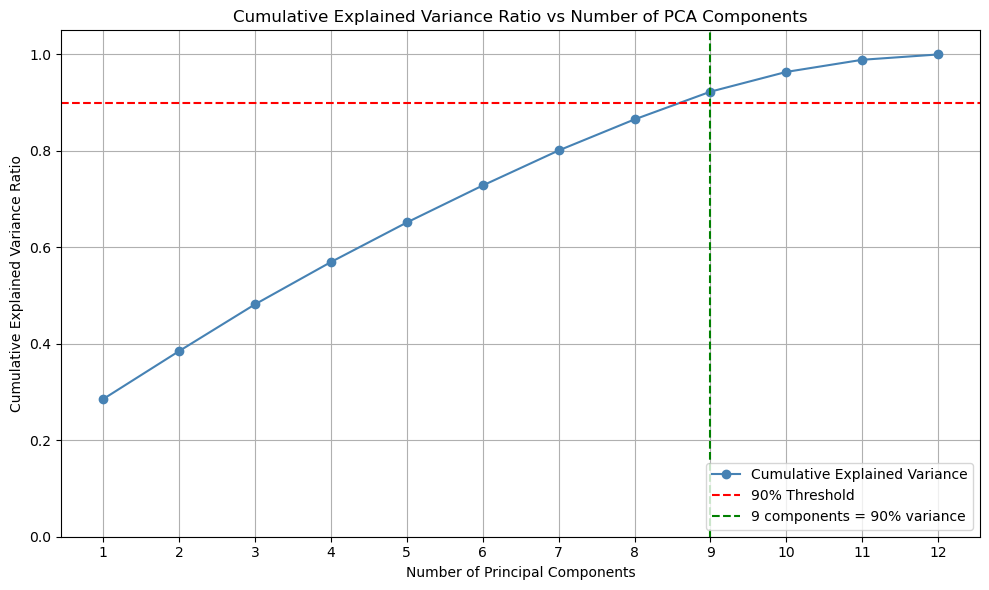

In [44]:
def plot_cumulative_explained_variance(pca_model):
    """
    Parameters:
    -----------
    pca_model : sklearn.decomposition.PCA
        A fitted PCA model with the attribute 'explained_variance_ratio_', which is an array-like
        containing the variance explained by each principal component.

    Returns:
    --------
    matplotlib.axes.Axes
        The Axes object containing the cumulative explained variance ratio plot.
    """
    _, ax = plt.subplots(figsize=(10, 6))
    cumulative_variance = np.cumsum(pca_model.explained_variance_ratio_)
    n_components = len(cumulative_variance)
    components_range = range(1, n_components + 1)

    # Plot cumulative explained variance line
    ax.plot(components_range, cumulative_variance, marker='o', linestyle='-', color='steelblue', label='Cumulative Explained Variance')

    # Add threshold reference line at 90%
    ax.axhline(y=0.90, color='red', linestyle='--', label='90% Threshold')

    # Mark the exact component where threshold is crossed
    n_comp_90 = get_n_components(pca_model, threshold=0.90)
    ax.axvline(x=n_comp_90, color='green', linestyle='--', label=f'{n_comp_90} components = 90% variance')

    ax.set_xlabel('Number of Principal Components')
    ax.set_ylabel('Cumulative Explained Variance Ratio')
    ax.set_title('Cumulative Explained Variance Ratio vs Number of PCA Components')
    ax.set_xticks(components_range)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right')
    ax.grid(True)

    plt.tight_layout()
    plt.show()
    
    return ax



ax1 = plot_cumulative_explained_variance(pca)

__Task 1.11__

__WHAT DO YOU THINK?__  
In your own words, briefly explain how does the graph above help us in determining the appropriate number of components to select so that it results in a simpler model and less computational expense?

Write your answer in the variable `answer_1_11` below.

In [45]:
# Write your answer here (between the triple quotes)
answer_1_11 = """
The graph helps us find the 'sweet spot' — the point where we capture enough variance
without using more components than necessary.

From the plot, the curve climbs quickly at first, then flattens out around 9 components,
where ~91% of the variance is already explained. After that, each additional component
barely moves the needle. So instead of using all 12 features, we can drop down to just 9
and lose almost nothing meaningful.

This gives us a simpler, faster model — which is exactly what we want for clustering.
"""

## 2. K-Means Clustering

Perform K-Means clustering on a PCA-transformed data to group similar songs together based on their audio features.

__Task 2.1__

Using the result from Task 1.9, apply PCA transformation on `data_sub_scaled` to reduce its dimensionality.

- Create a new PCA object called `pca_final` with `n_components` set to the 
value returned by `get_n_components()` using the default threshold, and `random_state=42`.
- Fit and transform `data_sub_scaled` using `pca_final`.
- Save the transformed data to a DataFrame called `data_pca` with column names 
as `PC1`, `PC2`, and so on.

In [ ]:
...



print(f"Original shape  : {data_sub_scaled.shape}")
print(f"Transformed shape: {data_pca.shape}")
data_pca.head()

__Task 2.2__

To determine the optimal number of clusters for K-Means, complete the 
function `plot_elbow_curve` that takes the following parameters:
- `data` : the PCA-transformed DataFrame to cluster
- `max_k` : the maximum number of clusters to try (default value of `10`)

The function should:
- Fit K-Means on `data` for `k` values from `1` to `max_k` (inclusive)
- Collect the **inertia** (within-cluster sum of squares) for each `k`
- Plot inertia vs number of clusters as a line plot with markers
- Label the x-axis as `"Number of Clusters (k)"` and y-axis as `"Inertia"`
- Title the plot as `"Elbow Curve for K-Means Clustering"`
- Return the matplotlib Axes object

Use `random_state=42` for all K-Means objects.

Then call `plot_elbow_curve` with `data_pca` and save the returned 
Axes object to `ax_elbow`.

In [ ]:
def plot_elbow_curve(data, max_k=10):
    """
    Plot the elbow curve for K-Means clustering to help determine
    the optimal number of clusters.

    Parameters
    ----------
    data : pd.DataFrame
        The PCA-transformed data to cluster.
    max_k : int, optional
        The maximum number of clusters to try. Default is 10.

    Returns
    -------
    matplotlib.axes.Axes
        The Axes object containing the elbow curve plot.
    """
    inertias = []
    k_values = range(1, max_k + 1)

    ...

    _, ax = plt.subplots(figsize=(10, 6))
    ...

    return ax



ax_elbow = plot_elbow_curve(data_pca)

__Task 2.3__

Based on the elbow curve plotted above, identify the optimal number of 
clusters where the inertia starts to decrease more slowly (the "elbow point").

Assign the optimal number of clusters to the variable `optimal_k`.

In [ ]:
optimal_k = ...

__Task 2.4__

Fit a K-Means model on `data_pca` using `optimal_k` as the number of 
clusters and `random_state=42` (rest is default params). Save the fitted model to a variable called `kmeans`.

Then, assign the cluster labels predicted by the model to a new column 
called `cluster` in a copy of `data_pca` called `data_pca_copy`.

In [ ]:
kmeans = ...
...



data_pca_copy.head()

__Task 2.5__

Create a scatter plot to visualize the K-Means clusters using `PC1` 
and `PC2` from `data_pca_copy`. 

Complete the function `plot_clusters` that takes the following parameters:
- `data` : the PCA-transformed DataFrame with a `cluster` column
- `x` : the column name for the x-axis (default `"PC1"`)
- `y` : the column name for the y-axis (default `"PC2"`)

The function should:
- Create a scatter plot with each point colored by its cluster label
- Label the x-axis and y-axis with the respective column names
- Title the plot as `"K-Means Clustering Results"`
- Return the matplotlib Axes object

Then call `plot_clusters` with `data_pca_copy` and save the returned 
Axes object to `ax_clusters`.

In [ ]:
def plot_clusters(data, x="PC1", y="PC2"):
    """
    Visualize K-Means clustering results using a scatter plot.

    Parameters
    ----------
    data : pd.DataFrame
        The PCA-transformed DataFrame containing cluster labels
        in a column named 'cluster'.
    x : str, optional
        Column name for the x-axis. Default is 'PC1'.
    y : str, optional
        Column name for the y-axis. Default is 'PC2'.

    Returns
    -------
    matplotlib.axes.Axes
        The Axes object containing the cluster scatter plot.
    """
    _, ax = plt.subplots(figsize=(10, 6))
    ...
    return ax



ax_clusters = plot_clusters(data_pca_copy)

__Task 2.6__

While the elbow method helps us visually identify the optimal number of clusters, we can further validate our choice using the **Silhouette Score** 
— a metric that measures how well each data point fits within its assigned cluster compared to other clusters.

The silhouette score ranges from **-1 to 1**:
- **Close to 1** : the data point is well-matched to its own cluster and 
poorly matched to neighbouring clusters (good clustering)
- **Close to 0** : the data point is near the boundary between two clusters
- **Close to -1** : the data point may have been assigned to the wrong cluster

Complete the function `plot_silhouette_scores` that takes the following parameters:
- `data` : the PCA-transformed DataFrame to cluster
- `k_range` : a list or range of `k` values to evaluate (default `range(2, 11)`)

The function should:
- Fit K-Means on `data` for each `k` in `k_range` using `random_state=42`
- Compute the **silhouette score** for each `k` using `silhouette_score` from `sklearn.metrics`
- Plot silhouette score vs number of clusters as a line plot with markers
- Label the x-axis as `"Number of Clusters (k)"` and y-axis as 
`"Silhouette Score"`
- Title the plot as `"Silhouette Score for K-Means Clustering"`
- Return a **tuple** of `(ax, scores_dict)` where `scores_dict` is a 
dictionary mapping each `k` to its silhouette score

Then call `plot_silhouette_scores` with `data_pca`, unpack the result 
and save to `ax_silhouette` and `silhouette_scores` respectively.

In [ ]:
def plot_silhouette_scores(data, k_range=range(2, 11)):
    """
    Compute and plot silhouette scores for K-Means clustering
    across a range of k values to help evaluate clustering quality.

    Parameters
    ----------
    data : pd.DataFrame
        The PCA-transformed data to cluster.
    k_range : range or list, optional
        The range of k values to evaluate. Default is range(2, 11).

    Returns
    -------
    tuple : (matplotlib.axes.Axes, dict)
        - Axes object containing the silhouette score plot.
        - Dictionary mapping each k to its silhouette score.
    """
    scores_dict = {}
    ...
    return ax, scores_dict



ax_silhouette, silhouette_scores = plot_silhouette_scores(data_pca)

print("Silhouette Scores:")
for k, score in silhouette_scores.items():
    print(f"  k={k}: {score:.4f}")

__Task 2.7__

**WHAT DO YOU THINK?**  
Based on the silhouette scores computed above, which value of `k` gives the highest silhouette score? Does it agree with your choice from the elbow method?

The silhouette score plot and elbow curve may or may not suggest different optimal values of `k`. 

In your own words, briefly explain:
1. Why the two methods might agree/disagree
2. What is value of the optimal silhouette score found and what can it tell us about the quality of the clusters formed?

Write your answer in the variable `answer_2_7` below.

In [ ]:
# Write your answer here (between the triple quotes)
answer_2_7 = """
...
"""

---

## Part B — Titanic Survival Prediction

## 1. Data Loading and Cleaning

__Task 1.1__

Load the Titanic dataset from the provided CSV files into pandas DataFrames called `train_data` and `test_data`.

In [ ]:
train_data = ...
test_data = ...

In [ ]:
train_data.shape, test_data.shape

__Task 1.2__

Perform exploration of the dataset to understand more about its structure, content and take note of any interesting patterns or anomalies. Feel free to do any kind of exploration in this task.

__Task 1.3__  

Based on your exploration of the dataset, identify and list down any data quality issues you find in the dataset. Handle the data quality issues you identified by performing appropriate data cleaning steps. You can choose to handle the issues in any way you see fit (e.g., dropping rows, filling missing values, etc.).

Complete the function `clean_data` that takes a DataFrame as input and returns a cleaned version of the DataFrame after handling the identified data quality issues.

In [ ]:
import pandas as pd

def clean_data(data: pd.DataFrame) -> pd.DataFrame:
    """
    Clean the dataset and return a cleaned version.
    
    Parameters:
        data (pd.DataFrame): The raw Titanic dataset.
    
    Returns:
        pd.DataFrame: The cleaned dataset.
    """
    ...

Invoke the `clean_data` function on both `train_data` and `test_data` and save the cleaned datasets to `train_data_cleaned` and `test_data_cleaned` respectively.

In [ ]:
train_data_cleaned = ...
test_data_cleaned = ...

__Task 1.4__  

Separate the features and target variable from the cleaned training and test datasets.

In [ ]:
# Separate features and target variable (DO NOT modify the variable names)
X_train_ti = ...
y_train_ti = ...

X_test_ti = ...
y_test_ti = ...

## 2. Data Preprocessing and Modeling

__Task 2.1__  

Continue with the cleaned training and test datasets, perform any necessary __preprocessing__ steps to prepare the data for modeling.

Save your final cleaned and preprocessed training and test sets to variables `X_train_ti_final`, `y_train_ti_final`, `X_test_ti_final`, and `y_test_ti_final` respectively.

These variables will be used for model training and evaluation.

In [ ]:
# Save the preprocessed data to new variables (DO NOT modify the variable names)
X_train_ti_final = ...
X_test_ti_final = ...

y_train_ti_final = ...
y_test_ti_final = ...

Use the above variables for the rest of the assignment for training and evaluating your model.

Train a decision tree classifier on the preprocessed training data and evaluate its performance on both the training and test sets. Your goal is to train a model that performs reasonably well on both sets without overfitting or underfitting while also ensuring that accuracy is as high as possible on the test set.

Save your final model to variable `best_model`.

In [ ]:
# save your best model here (DO NOT modify the variable name)
best_model = ...

<div style="display: flex; align-items: center; gap: 8px; margin: 12px 0; color: #868181;">
  <hr style="flex: 1; border: none; border-top: 1px solid #ccc;">
  <span style="font-size: 1.2em;">END ASSIGNMENT</span>
  <hr style="flex: 1; border: none; border-top: 1px solid #ccc;">
</div>
